In [4]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv('carvana - carvana.csv')

You are given a dataset about the cars' price and miles driven of different cars throughout the different years. The link of the dataset: https://tinyurl.com/2r24n45l. Your tasks are

make a pivot table of the brands (the required brands are given below) from the "Year" 2018 to the year 2022 in which the "Price" is shown as average values and "Miles" are in median values. In this pivote table, every row represents a particular brand and each column represents either average "Price" of a partucular year or median values of "Miles" of a particular year.
At the end plot a kde chart for the "Price" and "Miles" by using your pivot table.
There are some challenges to solve this task:

There is no column that is represented to the brand name of the car. You have to find out on your own.
Some values of "Years" column are misleading. You have to reset this column too that every value should tell a valid meaning.

In [6]:
df.head()

,Name,Year,Miles,Price
0,Chevrolet Trax,2018,41946,16990
1,GMC Terrain,2020,45328,23990
2,Jeep Wrangler,2012,81068,21590
3,Jeep Renegade,2019,35372,21590
4,BMW X,20173,68992,22990


<Axes: ylabel='Density'>

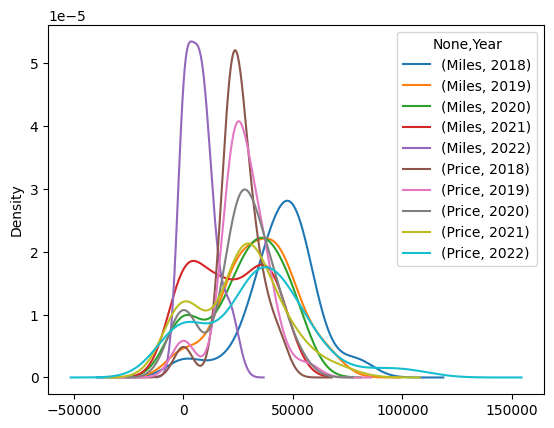

In [7]:
df['brand']=df['Name'].str.split(' ',n=1).str.get(0)
df['Year']=df['Year'].astype(str)
df['Year']=df['Year'].str[:4].astype(int)
df[(df['Year']>=2018) & (df['Year']<=2022)].pivot_table(index='brand',columns='Year',aggfunc={'Price':'mean','Miles':'median'},fill_value=0).plot(kind='kde')


You are given a dataset of Daily Power Generation in India of regional wise of all Power Stations. Link of the dataset: https://tinyurl.com/2nq6kugt

Task

In this dataset, there are many columns. Two of them are Actual(MU) and Excess(+) / Shortfall (-). Actual(MU) represents the actual power generation. Excess(+) / Shortfall (-) tells is that generated power is excess or shortfall for that particular day of a power station. You have to find out what should be the actual power generation required for that day by the power stations that there would not be any excess or shorfall power. For the result, make a new column.
Find out the month of the day and store it as a new column.
Find out top 10 frequently appeared power stations in this dataframe.
Next create a pivot table of which every row represents a power station and every column represents a month in a order. Like January, February, March...
It is hard to get inside if you look through the only pivot table. So plot the pivot table.

In [8]:
ps=pd.read_csv('PowerGeneration - PowerGeneration.csv')

In [35]:
ps.head(2)

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation,day_name,Actual Power Needed,Month
0,2017-09-01,Delhi,2235.4,135.0,0.0,135.0,0,13,18,5.0,0.0,Friday,13.0,September
1,2017-09-01,Haryana,2720.0,2470.0,0.0,2470.0,0,28,7,-21.8,0.0,Friday,28.8,September


In [34]:
ps['Dates']=pd.to_datetime(ps['Dates'])
ps['day_name']=ps['Dates'].dt.day_name()
ps['Actual Power Needed']=ps['Actual(MU)']-ps['Excess(+) / Shortfall (-)']
ps.head(2)

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation,day_name,Actual Power Needed,Month
0,2017-09-01,Delhi,2235.4,135.0,0.0,135.0,0,13,18,5.0,0.0,Friday,13.0,September
1,2017-09-01,Haryana,2720.0,2470.0,0.0,2470.0,0,28,7,-21.8,0.0,Friday,28.8,September


In [ ]:
# Find out the month of the day and store it as a new column.
ps['Month']=ps['Dates'].dt.month_name()
ps.head(2)

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation,day_name,Actual Power Needed,Month
0,2017-09-01,Delhi,2235.4,135.0,0.0,135.0,0,13,18,5.0,0.0,Friday,13.0,September
1,2017-09-01,Haryana,2720.0,2470.0,0.0,2470.0,0,28,7,-21.8,0.0,Friday,28.8,September


In [62]:
# Find out top 10 frequently appeared power stations in this dataframe.
ps['Power Station'].value_counts().head(10).index

Index(['NTPC Ltd.', 'NHPC', 'NPCIL', 'GMR ENERG', 'APL', 'JPPVL', 'NLC',
       'JSWEL', 'TATA PCL', 'IBPIL'],
      dtype='str', name='Power Station')

<Axes: xlabel='Power Station'>

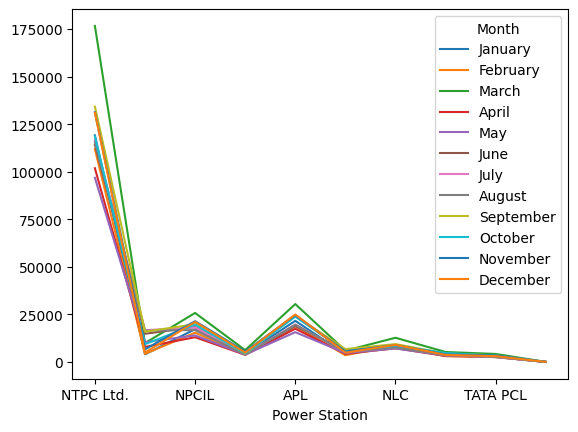

In [66]:
# Next create a pivot table of which every row represents a power station and every column represents a month in a order. Like January, February, March...
# It is hard to get inside if you look through the only pivot table. So plot the pivot table.

ordered_months = ['January', 'February', 'March', 'April', 'May', 'June', 
                  'July', 'August', 'September', 'October', 'November', 'December']

pivoted_table=ps.pivot_table(index='Power Station',columns='Month',values='Actual(MU)',fill_value=0,aggfunc='sum')[ordered_months]
top_5_indexes=['NTPC Ltd.', 'NHPC', 'NPCIL', 'GMR ENERG', 'APL', 'JPPVL', 'NLC',
       'JSWEL', 'TATA PCL', 'IBPIL']
pivoted_table.loc[top_5_indexes].plot(kind='line')

Q-4 You are given a file question-answer.csv. Your task is to make a dataframe from it with two columns - question and answers.
Questions in the file start from Q<number>; E.g. Q1 denotes question no. 1
Answers starts from Ans<number>; Eg. Ans1 denotes answer of question no 1
MAke sure you look at columns name carefully
CSV File - "https://drive.google.com/file/d/10rmV3XrVtzpDTtYZF3UtCdcU0ajBJjGY/view?usp=share_link"

In [110]:
qs=pd.read_csv('question-answer.csv')
qs.drop(columns='Unnamed: 0',inplace=True)


In [162]:
# 1 way
questions=qs.iloc[0::2]
questions.reset_index(inplace=True)
questions.drop(columns='index',inplace=True)
answers=qs.iloc[1::2]
answers.reset_index(inplace=True)
answers.drop(columns='index',inplace=True)

answers.reset_index(inplace=True)
answers
questions.reset_index(inplace=True)
questions

new_df1=questions.merge(answers,on='index').rename(columns={'2_x':'Questions','2_y':'Answers'}).drop(columns='index')
new_df1

,Questions,Answers
0,Q1-What is Data Science?,"Ans1-Data Science combines statistics, maths, ..."
1,Q2-2. How is logistic regression done?,Ans2-Logistic regression measures the relation...
2,Q3-How do you build a random forest model?,Ans3-A random forest is built up of a number o...
3,Q4-How can you avoid overfitting your model?,Ans4-Overfitting refers to a model that is onl...
4,Q5-You are given a data set consisting of vari...,Ans5-The following are ways to handle missing ...
5,Q6-What is bag of words? How we can use it for...,Ans6-Bag of Words is a representation of text ...
6,Q7-How can we use machine learning for text cl...,Ans7-Machine learning classification algorithm...
7,Q8-What is a time series?,Ans8-A time series is a set of observations or...
8,Q9-How is time series different from the usual...,Ans9-The principle behind causal forecasting i...
9,Q10-What are the different types of joins? Wha...,Ans10-(INNER) JOIN: Returns records that have ...


In [163]:
# Second_way
reshaped_grid=qs['2'].values.to_numpy().reshape(-1,2)
new_df=pd.DataFrame(reshaped_grid,columns=['Questions','Answers'])
new_df

,Questions,Answers
0,Q1-What is Data Science?,"Ans1-Data Science combines statistics, maths, ..."
1,Q2-2. How is logistic regression done?,Ans2-Logistic regression measures the relation...
2,Q3-How do you build a random forest model?,Ans3-A random forest is built up of a number o...
3,Q4-How can you avoid overfitting your model?,Ans4-Overfitting refers to a model that is onl...
4,Q5-You are given a data set consisting of vari...,Ans5-The following are ways to handle missing ...
5,Q6-What is bag of words? How we can use it for...,Ans6-Bag of Words is a representation of text ...
6,Q7-How can we use machine learning for text cl...,Ans7-Machine learning classification algorithm...
7,Q8-What is a time series?,Ans8-A time series is a set of observations or...
8,Q9-How is time series different from the usual...,Ans9-The principle behind causal forecasting i...
9,Q10-What are the different types of joins? Wha...,Ans10-(INNER) JOIN: Returns records that have ...


In [175]:
# Print Question and answer of those questions which does not contains any question mark (?).
new_df[~new_df['Questions'].str.contains('?',regex=False)]

,Questions,Answers


Q 6-10 LOG and EMPLOYEE
Show activity details month wise. Show count for each activity
Find employee who did most activity in January month.
Employee who have worked most no of times on Weekends.
Which activity is logged most on buisness days.
Week Days wise activity table.
log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
employee = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")

Note(for common field):- Employee file has EMPLOYEE_ID and LOG file has emp_id

In [312]:
log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
employee = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")

In [339]:
# Show activity details month wise. Show count for each activity
log_file['dt']=pd.to_datetime(log_file['dt'])
log_file['month']=log_file['dt'].dt.month_name()

ordered_months = ['January', 'February', 'March', 'April', 'May', 'June', 
                  'July', 'August', 'September', 'October', 'November', 'December']
log_file.pivot_table(index='month',columns='activity',values='EMPLOYEE_ID',aggfunc='count').loc[ordered_months]

activity,Checking,Cleaning,Inspection,Repair
month,,,,
January,7,10,9,5
February,7,7,4,10
March,8,6,5,12
April,5,11,9,5
May,5,8,7,11
June,5,7,8,10
July,6,6,14,5
August,8,10,9,4
September,8,3,12,7


In [314]:
log_file.head()
log_file.rename(columns={'emp_id':'EMPLOYEE_ID'},inplace=True)

In [340]:
# Find employee who did most activity in January month.
merged=log_file.merge(employee,on='EMPLOYEE_ID')
merged[merged['month']=='January']['FIRST_NAME'].value_counts().head(1)

FIRST_NAME
Payam    3
Name: count, dtype: int64

In [341]:
# Employee who have worked most no of times on Weekends.
merged['Day']=merged['dt'].dt.day_name()
merged[merged['Day'].isin(['Saturday','Sunday'])]['FIRST_NAME'].value_counts().head(3)

FIRST_NAME
Daniel       5
Alexander    5
James        5
Name: count, dtype: int64

In [342]:
# Which activity is logged most on buisness days.
merged[~merged['Day'].isin(['Saturday','Sunday'])]['activity'].value_counts().head(1)

activity
Inspection    62
Name: count, dtype: int64

In [343]:
# Week Days wise activity table.
ordered_days=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
merged.pivot_table(index='Day',columns='activity',values='EMPLOYEE_ID',aggfunc='count').loc[ordered_days]

activity,Checking,Cleaning,Inspection,Repair
Day,,,,
Monday,9,9,11,12
Tuesday,12,8,13,11
Wednesday,13,9,9,9
Thursday,8,14,14,11
Friday,7,15,15,8
Saturday,9,8,6,11
Sunday,11,9,13,11


There are missing value in first name of employee. Fill it using email and last name field.
E.g- email -> JMURMAN and last_name -> 'Urman' -> so make it's first name as 'JM', Sort of (Email- lastname).

Email is constructed from initials of first name concate with lastname. Your Task is to fill first name initials in missing data.

You can see email field don't have any domain name. Change this to full email addreess with domain as 'campusx.com'. E.g- Email field -> JMURMAN result -> JMURMAN@CAMPUSX.COM

Show Full Name of all the employees whose name starts with 'A' and has done any of these activity ['Incpection', 'Cleaning', 'Checking]

In [319]:
employee.head(2)

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING
1,101,Neena,Kochhar,NKOCHHAR


In [ ]:
missing=employee[employee['FIRST_NAME'].isna()].apply(lambda row:row['EMAIL'][:-len(str(row['LAST_NAME']))],axis=1)
employee['FIRST_NAME'].fillna(missing)
employee.head(13)

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING
1,101,Neena,Kochhar,NKOCHHAR
2,102,Lex,De Haan,LDEHAAN
3,103,Alexander,Hunold,AHUNOLD
4,104,Bruce,Ernst,BERNST
5,105,David,Austin,DAUSTIN
6,106,Valli,Pataballa,VPATABAL
7,107,Diana,Lorentz,DLORENTZ
8,108,Nancy,Greenberg,NGREENBE
9,109,Daniel,Faviet,DFAVIET


In [336]:
employee['EMAIL']=employee['EMAIL']+"@CAMPUSX.COM"

In [344]:
employee.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING@CAMPUSX.COM
1,101,Neena,Kochhar,NKOCHHAR@CAMPUSX.COM
2,102,Lex,De Haan,LDEHAAN@CAMPUSX.COM
3,103,Alexander,Hunold,AHUNOLD@CAMPUSX.COM
4,104,Bruce,Ernst,BERNST@CAMPUSX.COM


In [345]:
merged

,Log_ID,dt,dept,EMPLOYEE_ID,activity,eqpt,month,FIRST_NAME,LAST_NAME,EMAIL,Day
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,January,Alexander,Khoo,AKHOO@CAMPUSX.COM,Friday
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,January,David,Austin,DAUSTIN@CAMPUSX.COM,Saturday
2,1002,2022-01-09,Dept3,112,Inspection,CPU,January,JM,Urman,JMURMAN@CAMPUSX.COM,Sunday
3,1003,2022-01-10,Dept4,120,Inspection,UPS,January,Matthew,Weiss,MWEISS@CAMPUSX.COM,Monday
4,1004,2022-01-11,Dept3,138,Checking,Battery,January,Stephen,Stiles,SSTILES@CAMPUSX.COM,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...
290,1360,2023-01-02,Dept2,122,Repair,AC,January,Payam,Kaufling,PKAUFLING@CAMPUSX.COM,Monday
291,1361,2023-01-03,Dept4,116,Checking,Server,January,Shelli,Baida,SBAIDA@CAMPUSX.COM,Tuesday
292,1362,2023-01-04,Dept4,110,Checking,CPU,January,John,Chen,JCHEN@CAMPUSX.COM,Wednesday
293,1363,2023-01-05,Dept4,102,Inspection,AC,January,Lex,De Haan,LDEHAAN@CAMPUSX.COM,Thursday


In [ ]:
# Show Full Name of all the employees whose name starts with 'A' and has done any of these activity ['Incpection', 'Cleaning', 'Checking]
list1=['Incpection', 'Cleaning', 'Checking']

merged['FULL NAME']=merged['FIRST_NAME']+" "+merged['LAST_NAME']

In [364]:
merged[(merged['FIRST_NAME'].str.startswith('A')) & (merged['activity'].isin(list1))]['FULL NAME'].drop_duplicates().reset_index(drop=True)

0      Alexander Khoo
1    Alexander Hunold
Name: FULL NAME, dtype: str